# Employee Productivity Analysis
This notebook cleans the dataset and explores relationships connected to employee productiveness to further our understanding of where efficient business decisions can be made.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load dataset and display basic information
df = pd.read_csv("data/raw_employee_dataset.csv")

print(f"Shape: {df.shape}")

print("\nColumn/s with missing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nDataset Info:")
df.info()


Shape: (1197, 15)

Column/s with missing values:
wip    506
dtype: int64

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non

In [6]:
# Remove column with too many missing values
df = df.drop(columns=["wip"], errors="ignore")

# Remove missing rows
df = df.dropna()

# Outlier removal using Z-score on "no_of_workers"
z = (df["no_of_workers"] - df["no_of_workers"].mean()) / df["no_of_workers"].std()
df_clean = df[z.abs() < 1.5].copy()

print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")
df_clean.head()

Original rows: 1197
Clean rows: 1196


,date,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,3/1/2015,Quarter1,finishing,Sunday,1,0.60,3.94,3360,0,0.0,0,0,8.0,0.448722
1,3/2/2015,Quarter1,finishing,Monday,1,0.65,3.94,3360,0,0.0,0,0,8.0,0.537919
2,3/3/2015,Quarter1,finishing,Tuesday,1,0.70,3.94,3360,0,0.0,0,0,8.0,0.555431
3,3/4/2015,Quarter1,finishing,Wednesday,1,0.70,3.94,960,0,0.0,0,0,8.0,0.806879
4,3/5/2015,Quarter1,finishing,Thursday,1,0.70,3.94,960,0,0.0,0,0,8.0,0.812625


In [7]:
# FEATURE ENGINEERING (DEFINE METRICS)

# Productivity gap
df_clean["productivity_gap"] = (
    df_clean["actual_productivity"] - df_clean["targeted_productivity"]
)

# Efficiency per worker
df_clean["productivity_per_worker"] = (
    df_clean["actual_productivity"] / df_clean["no_of_workers"]
)

In [8]:
# TEAM-LEVEL SUMMARY (MAIN DATASET)
team_summary = df_clean.groupby("team").agg({
    "actual_productivity": "mean",
    "targeted_productivity": "mean",
    "productivity_gap": "mean",
    "over_time": "mean",
    "incentive": "mean",
    "no_of_workers": "mean"
}).reset_index()

# Ensure teams are ordered numerically
team_summary["team"] = team_summary["team"].astype(int)
team_summary = team_summary.sort_values("team")

In [9]:
# VISUAL ANALYSIS SETUP

# Define percent difference from target productivity
df_clean["productivity_pct_diff"] = (
    (df_clean["actual_productivity"] - df_clean["targeted_productivity"])
    / df_clean["targeted_productivity"]
) * 100

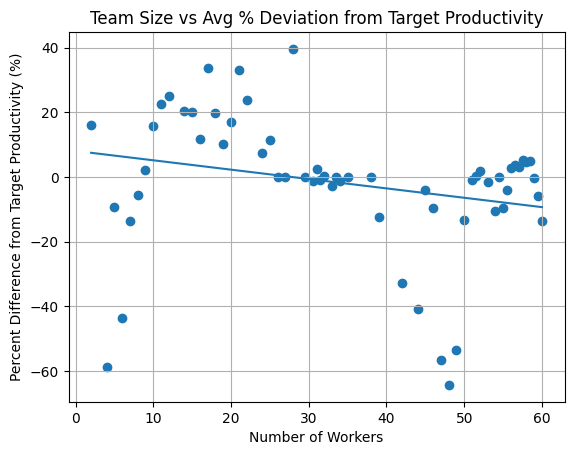

                 productivity_pct_diff  idle_time    over_time  incentive
team_size_group                                                          
0-30                          4.272560   0.000000  1933.647059  29.752941
30-60                         0.379755   1.274052  6523.804665  44.444606


In [31]:
# 1. Team Size vs Productivity Percent Deviation from Target
grouped = df_clean.groupby("no_of_workers")["productivity_pct_diff"].mean().reset_index()

# Ensure proper ordering
grouped = grouped.sort_values("no_of_workers")

x = grouped["no_of_workers"]
y = grouped["productivity_pct_diff"]
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.title("Team Size vs Avg % Deviation from Target Productivity")
plt.xlabel("Number of Workers")
plt.ylabel("Percent Difference from Target Productivity (%)")
plt.grid(True)
plt.show()

# Time size correlation with other metrics
df_clean["team_size_group"] = df_clean["no_of_workers"].apply(
    lambda x: "0-30" if x <= 30 else "30-60"
)

size_group_summary = df_clean.groupby("team_size_group")[[
    "productivity_pct_diff",
    "idle_time",
    "over_time",
    "incentive"
]].mean()

print(size_group_summary)

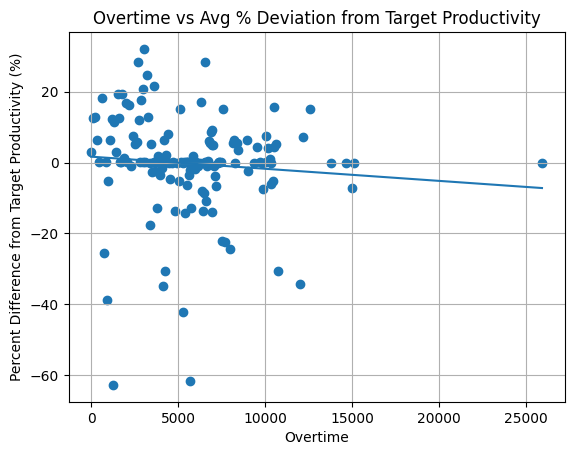

In [32]:
# 2. Overtime vs % Deviation (Overall)
agg_ot = df_clean.groupby("over_time")["productivity_pct_diff"].mean().reset_index()

x = agg_ot["over_time"]
y = agg_ot["productivity_pct_diff"]

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.title("Overtime vs Avg % Deviation from Target Productivity")
plt.xlabel("Overtime")
plt.ylabel("Percent Difference from Target Productivity (%)")
plt.grid(True)
plt.show()

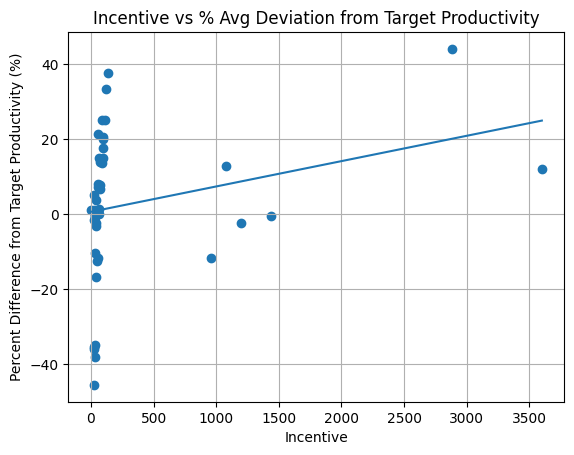

In [33]:
# 3. Incentive vs % Deviation (Overall)
agg = df_clean.groupby("incentive")["productivity_pct_diff"].mean().reset_index()

x = agg["incentive"]
y = agg["productivity_pct_diff"]

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.figure()
plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.title("Incentive vs % Avg Deviation from Target Productivity")
plt.xlabel("Incentive")
plt.ylabel("Percent Difference from Target Productivity (%)")
plt.grid(True)
plt.show()

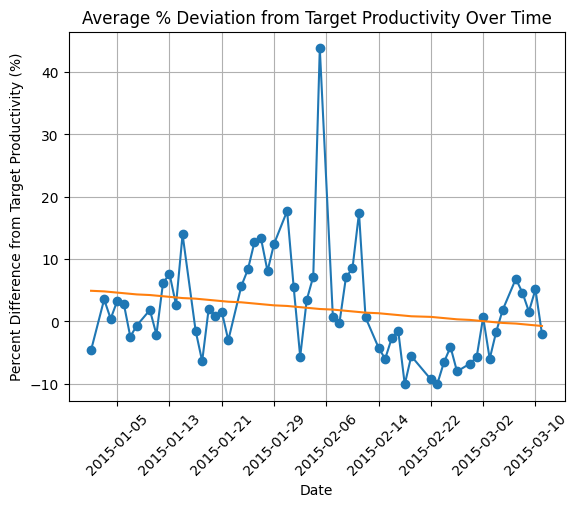

In [34]:
# 4. % Deviation Over Time (Overall)
df_clean['date'] = pd.to_datetime(df_clean['date'])

time_summary = df_clean.groupby("date")["productivity_pct_diff"].mean().reset_index()

x = np.arange(len(time_summary))
y = time_summary["productivity_pct_diff"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.plot(time_summary["date"], y, marker='o')
plt.plot(time_summary["date"], m*x + b)
plt.title("Average % Deviation from Target Productivity Over Time")
plt.xlabel("Date")
plt.ylabel("Percent Difference from Target Productivity (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.show()

## Observations and Business Insights

### 1. Team Size Effects
- Team size shows a weak, non-linear relationship with deviation from target productivity, ranging approximately from +8% to -8%.
- Mid-sized teams (~10–30 members) show slightly more favorable performance relative to larger teams (~40+ members), though the relationship is not consistent enough to suggest a strong trend.
- These patterns suggest that team size alone is not a strong predictor of productivity deviation, and "target_productivity" may already be adjusted by to account for different team sizes, reducing the value of team size as a predictor of productivity. 

### 2. Overtime and Productivity
- Overtime shows a weak negative relationship with productivity deviation.
- This suggests diminishing returns, where increased working hours do not reliably translate into improved performance relative to targets.
- Higher overtime is also associated with increased idle time, suggesting inefficiencies in how additional labor hours are utilized.

### 3. Incentives and Productivity
- Incentives show a small and inconsistent positive relationship with productivity deviation.
- While some higher incentive values correspond to improved performance, strong productivity is also observed at lower incentive levels.
- This suggests incentives alone are not a dominant driver of productivity in this dataset.

### 4. Productivity Over Time
- Productivity deviation shows a slight downward trend over time.
- One notable outlier in early February 2015 exhibits unusually high performance, likely reflecting a temporary condition.
- Outside of this event, performance remains relatively stable with minor fluctuations.

## Business Interpretation
- No single factor (team size, overtime, or incentives) strongly explains productivity deviation on its own.
- Team size and incentives have inconsistent correlations with productivity, suggesting they may function better as supporting mechanisms rather than primary drivers of productivity.
- The most consistent signal across analyses is that inefficiency-related variables (particularly idle time and ineffective overtime usage) are more closely associated with performance variation than structural variables like team size. Thus, improvements are more likely to come from reducing inefficiencies (idle time, workflow delays) than simply adjusting team size, increasing overtime, or offering more incentives.